In [2]:
import pandas as pd

df = pd.read_excel('BASE_1_Manga_Produtos.xlsx')

df.head(10)

,empresa,faturamento_empresa_brl,produto,tipo_cliente,mercado_principal,indice_concorrencia_1a5,indice_valor_agregado_1a5,margem_media_percentual,indice_complexidade_produtiva_1a5,indice_capex_1a5,indice_escalabilidade_1a5,indice_exigencia_regulatoria_1a5,certificacoes_principais,indice_compatibilidade_refugo_1a5,indice_compatibilidade_operacao_fazenda_1a5
0,BRF Ingredients,5.300000e+10,Sorbet / picolé,B2B,Interno,2.0,3.5,45.66,4.0,1.0,1.0,3.0,ANVISA,2.0,1.0
1,Ambev (bebidas),7.200000e+10,Purê de manga asséptico,B2C,NaN,2.0,3.0,12.79,3.0,1.0,3.0,3.0,ANVISA,1.0,2.0
2,Bunge Brasil,9.500000e+10,Biocomposto / fertilizante orgânico,B2B,Externo,4.0,2.0,12.31,2.0,3.0,3.0,2.0,ANVISA,3.0,2.0
3,MangaVale Alimentos,4.800000e+08,Sabonete / hidratante com manga,B2B,Ambos,1.0,2.5,37.29,3.0,2.0,NaN,2.0,MAPA,2.0,2.0
4,Cutrale,3.000000e+10,Corante natural,B2B,Interno,3.0,3.5,13.45,4.0,2.0,4.0,3.0,MAPA,2.0,4.0
5,AgroDoce Nordeste,2.200000e+08,Óleo / manteiga de semente de manga,B2B,Externo,3.0,4.0,31.02,3.0,4.0,1.0,5.0,Internacional,3.0,3.0
6,VerdePulp Brasil,3.100000e+08,NaN,B2B,Interno,2.0,3.5,18.22,4.0,1.0,1.0,3.0,Nenhuma,3.0,1.0
7,NordFruit Export,5.400000e+08,Ração / ingrediente para ração animal,NaN,Interno,2.0,3.5,43.97,3.0,4.0,3.0,4.0,Internacional,2.0,4.0
8,Cutrale,3.000000e+10,Base para néctar,B2B,Interno,NaN,2.5,19.20,2.0,3.0,3.0,3.0,Internacional,2.0,3.0
9,Fazenda Sol do Vale,1.800000e+08,Óleo / manteiga de semente de manga,B2C,Externo,3.0,4.0,NaN,4.0,3.0,NaN,NaN,MAPA,2.0,2.0


In [3]:
df.isnull().sum()

empresa                                        91
faturamento_empresa_brl                        76
produto                                        94
tipo_cliente                                   90
mercado_principal                              80
indice_concorrencia_1a5                        84
indice_valor_agregado_1a5                      98
margem_media_percentual                        79
indice_complexidade_produtiva_1a5              78
indice_capex_1a5                               91
indice_escalabilidade_1a5                      90
indice_exigencia_regulatoria_1a5               69
certificacoes_principais                       79
indice_compatibilidade_refugo_1a5              87
indice_compatibilidade_operacao_fazenda_1a5    67
dtype: int64

In [4]:
df["produto"].isnull().sum()
df.isnull().sum()

empresa                                        91
faturamento_empresa_brl                        76
produto                                        94
tipo_cliente                                   90
mercado_principal                              80
indice_concorrencia_1a5                        84
indice_valor_agregado_1a5                      98
margem_media_percentual                        79
indice_complexidade_produtiva_1a5              78
indice_capex_1a5                               91
indice_escalabilidade_1a5                      90
indice_exigencia_regulatoria_1a5               69
certificacoes_principais                       79
indice_compatibilidade_refugo_1a5              87
indice_compatibilidade_operacao_fazenda_1a5    67
dtype: int64

In [5]:
df["produto"].value_counts().tail(28)



produto
Pó de manga (spray-dried)                     67
Fibra alimentar de manga                      65
Concentrado de manga                          63
Base cosmética (extrato)                      63
Base para néctar                              63
Polpa congelada                               60
Geleia/compota                                60
Ingrediente antioxidante                      60
Pectina                                       59
Purê de manga asséptico                       59
Manga desidratada em pedaços                  58
Esfoliante natural                            58
Molho agridoce / culinário                    55
Subproduto industrial de bagaço processado    55
Biogás / energia                              54
Bebida alcoólica / fermentado                 54
Snack de manga desidratada                    52
Corante natural                               52
Suco pronto (NFC)                             52
Óleo / manteiga de semente de manga           51
Cubos IQF   

In [6]:
categorias = {
    "Alimentos & Bebidas (Produto Final)": [
        "Sorbet / picolé",
        "Suco pronto (NFC)",
        "Cubos IQF",
        "Geleia/compota",
        "Chutney de manga",
        "Molho agridoce / culinário",
        "Snack de manga desidratada",
        "Manga desidratada em pedacos",
        "Manga desidratada em pedaços",
        "Bebida funcional com manga",
        "Bebida alcoólica / fermentado"
    ],

    "Ingredientes Alimentícios & Funcionais (B2B)": [
        "Concentrado de manga",
        "Polpa congelada",
        "Purê de manga asséptico",
        "Base para néctar",
        "Pectina",
        "Fibra alimentar de manga",
        "Ingrediente antioxidante",
        "Corante natural",
        "Aroma / extrato natural",
        "Pó de manga (spray-dried)"
    ],

    "Cosméticos, Higiene & Perfumaria": [
        "Base cosmética (extrato)",
        "Esfoliante natural",
        "Sabonete / hidratante com manga",
        "Fragrância para perfumaria",
        "Óleo / manteiga de semente de manga"
    ],

    "Sustentabilidade, Energia & Bioinsumos": [
        "Biogás / energia",
        "Subproduto industrial de bagaço processado",
        "Biocomposto / fertilizante orgânico"
    ],

    "Nutrição Animal & Agro": [
        "Ração / ingrediente para ração animal"
    ]
}


def classificar_categoria(produto):
    for categoria, produtos in categorias.items():
        if produto in produtos:
            return categoria
    return "Categoria não definida"

df["categoria"] = df["produto"].apply(classificar_categoria)

df["categoria"].value_counts()


categoria
Ingredientes Alimentícios & Funcionais (B2B)    593
Alimentos & Bebidas (Produto Final)             548
Cosméticos, Higiene & Perfumaria                266
Sustentabilidade, Energia & Bioinsumos          154
Categoria não definida                           94
Nutrição Animal & Agro                           45
Name: count, dtype: int64

In [7]:
colunas_numericas = df.select_dtypes(include="number").columns

colunas_com_nulos = [
    col for col in colunas_numericas
    if df[col].isnull().sum() > 0
]

for col in colunas_com_nulos:
    df[col] = df[col].fillna(
        df.groupby("categoria")[col].transform("mean")
    )

df[colunas_com_nulos].isnull().sum()

faturamento_empresa_brl                        0
indice_concorrencia_1a5                        0
indice_valor_agregado_1a5                      0
margem_media_percentual                        0
indice_complexidade_produtiva_1a5              0
indice_capex_1a5                               0
indice_escalabilidade_1a5                      0
indice_exigencia_regulatoria_1a5               0
indice_compatibilidade_refugo_1a5              0
indice_compatibilidade_operacao_fazenda_1a5    0
dtype: int64

In [8]:
df.isnull().sum()

empresa                                        91
faturamento_empresa_brl                         0
produto                                        94
tipo_cliente                                   90
mercado_principal                              80
indice_concorrencia_1a5                         0
indice_valor_agregado_1a5                       0
margem_media_percentual                         0
indice_complexidade_produtiva_1a5               0
indice_capex_1a5                                0
indice_escalabilidade_1a5                       0
indice_exigencia_regulatoria_1a5                0
certificacoes_principais                       79
indice_compatibilidade_refugo_1a5               0
indice_compatibilidade_operacao_fazenda_1a5     0
categoria                                       0
dtype: int64

In [9]:
df['tipo_cliente'].value_counts()

tipo_cliente
B2B    1177
B2C     433
Name: count, dtype: int64

In [10]:
df['mercado_principal'].value_counts()

mercado_principal
Interno    823
Externo    419
Ambos      378
Name: count, dtype: int64

In [11]:
df['certificacoes_principais'].value_counts()

certificacoes_principais
MAPA             416
Nenhuma          407
ISO/HACCP        323
ANVISA           319
Internacional    156
Name: count, dtype: int64

In [12]:
df.groupby("produto")["margem_media_percentual"].describe()

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
Aroma / extrato natural,45.0,32.374868,10.231799,9.91,24.5000,34.050000,40.5400,50.32
Base cosmética (extrato),63.0,27.953606,9.777284,10.86,20.6300,26.580000,34.1900,50.44
Base para néctar,63.0,26.518382,10.945247,8.88,17.9700,24.660000,36.3200,48.49
Bebida alcoólica / fermentado,54.0,27.903387,9.591924,11.95,20.8750,28.260728,32.9625,49.13
Bebida funcional com manga,50.0,27.691244,9.239988,10.37,21.1550,27.480000,32.4475,51.47
Biocomposto / fertilizante orgânico,45.0,28.573772,12.016775,8.84,17.0100,30.450000,37.0200,52.55
Biogás / energia,54.0,26.925245,11.199634,7.70,16.7700,25.150000,36.8350,48.04
Chutney de manga,46.0,30.498324,10.784340,11.60,21.1975,30.310000,38.1900,49.01
Concentrado de manga,63.0,30.333779,10.459698,10.38,20.4050,30.720000,39.5100,48.98


In [13]:
df.groupby("categoria")["indice_concorrencia_1a5"].describe()

,count,mean,std,min,25%,50%,75%,max
categoria,,,,,,,,
Alimentos & Bebidas (Produto Final),548.0,2.937381,1.114089,1.0,2.0,3.0,4.0,5.0
Categoria não definida,94.0,2.923913,1.059861,1.0,2.0,3.0,4.0,5.0
"Cosméticos, Higiene & Perfumaria",266.0,3.083665,1.121392,1.0,2.0,3.0,4.0,5.0
Ingredientes Alimentícios & Funcionais (B2B),593.0,2.971171,1.079241,1.0,2.0,3.0,4.0,5.0
Nutrição Animal & Agro,45.0,2.886364,1.247104,1.0,2.0,3.0,4.0,5.0
"Sustentabilidade, Energia & Bioinsumos",154.0,3.088435,1.231000,1.0,2.0,3.0,4.0,5.0


In [14]:
df_polpa = df[df['produto'] == 'Polpa congelada']


In [15]:
qtd_polpa = df_polpa.shape[0]
print(f"Quantidade de registros de Polpa Congelada: {qtd_polpa}")


Quantidade de registros de Polpa Congelada: 60


In [16]:
total_registros = df.shape[0]
participacao = (qtd_polpa / total_registros) * 100

print(f"Participação da Polpa Congelada: {participacao:.2f}%")


Participação da Polpa Congelada: 3.53%


In [17]:
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
df['produto'] = df['produto'].astype(str).str.lower().str.strip()


In [19]:
df_polpa = df[df['produto'].str.contains('Biogás', na=False)]


In [20]:
print(f"Registros de Polpa Congelada: {df_polpa.shape[0]}")


Registros de Polpa Congelada: 0


In [21]:
colunas_numericas = [
    'faturamento_empresa_brl',
    'margem_media_percentual',
    'indice_concorrencia_1a5',
    'indice_valor_agregado_1a5',
    'indice_complexidade_produtiva_1a5',
    'indice_capex_1a5',
    'indice_escalabilidade_1a5',
    'indice_exigencia_regulatoria_1a5',
    'indice_compatibilidade_refugo_1a5',
    'indice_compatibilidade_operacao_fazenda_1a5'
]

estatisticas = df_polpa[colunas_numericas].describe()
estatisticas


,faturamento_empresa_brl,margem_media_percentual,indice_concorrencia_1a5,indice_valor_agregado_1a5,indice_complexidade_produtiva_1a5,indice_capex_1a5,indice_escalabilidade_1a5,indice_exigencia_regulatoria_1a5,indice_compatibilidade_refugo_1a5,indice_compatibilidade_operacao_fazenda_1a5
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_polpa['tipo_cliente'].value_counts()


Series([], Name: count, dtype: int64)

In [23]:
df_polpa['indice_escalabilidade_1a5'].value_counts()


Series([], Name: count, dtype: int64)

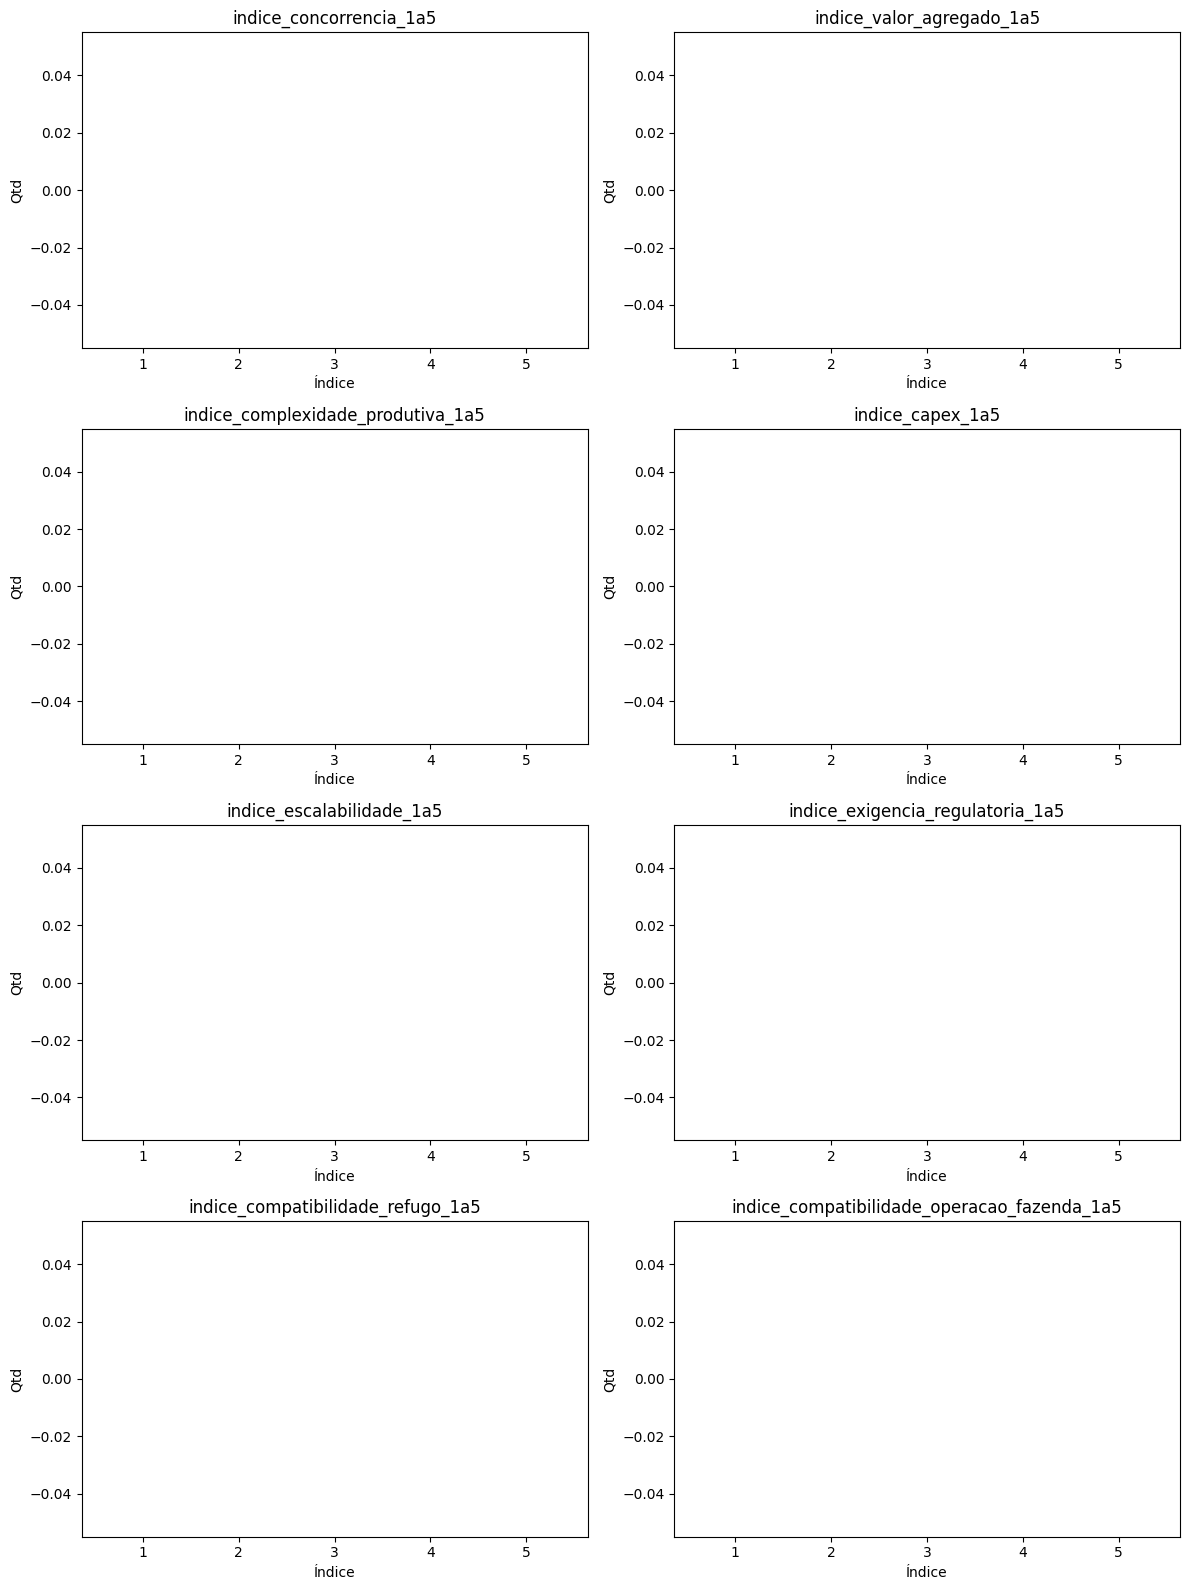

In [24]:
import math
import matplotlib.pyplot as plt

variaveis_1a5 = [
    'indice_concorrencia_1a5',
    'indice_valor_agregado_1a5',
    'indice_complexidade_produtiva_1a5',
    'indice_capex_1a5',
    'indice_escalabilidade_1a5',
    'indice_exigencia_regulatoria_1a5',
    'indice_compatibilidade_refugo_1a5',
    'indice_compatibilidade_operacao_fazenda_1a5'
]

cols_existentes = [c for c in variaveis_1a5 if c in df_polpa.columns]
n = len(cols_existentes)

ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols_existentes):
    contagem = (
        df_polpa[col]
        .value_counts(dropna=True)
        .reindex([1, 2, 3, 4, 5], fill_value=0)
    )

    axes[i].bar(contagem.index.astype(int), contagem.values)
    axes[i].set_title(col)
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xlabel('Índice')
    axes[i].set_ylabel('Qtd')

# Desligar eixos vazios (caso n seja ímpar)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
